# Alternative Knot Sorter

Here, we realize a knot sorter with respect to the Trefoil and Cinquefoil specifically by projecting into the l=3 and l=5 modes.

In [4]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

Let's start by creating the knots to be sorted. Load from the configuration file.

In [5]:
index = 4

stream = open(f"configs/ga{index}.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

num_phase_maps_near = cnfg['num_phase_maps_near']
num_phase_maps_far = cnfg['num_phase_maps_far']

num_of_phase_maps = num_phase_maps_near + num_phase_maps_far # Total number of phase maps
instance_name = cnfg['ga_instance'] # directory name of best phases

# Print the instance name (for reference)

print(instance_name)

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

tref_cinq_lens_two_prev


Initialize the field

In [6]:
# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

xx,yy=np.meshgrid(X ,Y)

r, phi= cart2pol(xx, yy)

Create OAM fields

In [7]:
list_of_OAMs = []

if (num_of_output_chans==2):
    output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
else: 
    output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation)

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
        
else:
    for ii in range(len(LG_modes)):
        ell, p = LG_modes[ii][0], LG_modes[ii][1]
        field = LG(r, phi, ell, p, w0, h, 0, k)
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))

Plot them

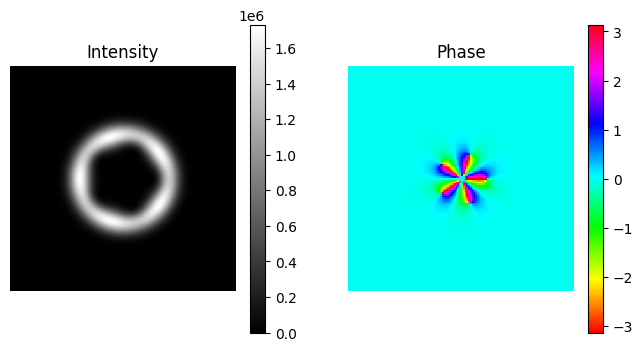

In [8]:
mode = 1

field = norm_field(list_of_OAMs[mode].oamBeam, h)
TotInt(field)

# Experiment 1: OAM Pitchforks

As a rough, theoretical approximation. We start by sending the knots towards pitchforks generating OAM. We can project to the desired mode by 'phase flattening' the incident mode. 

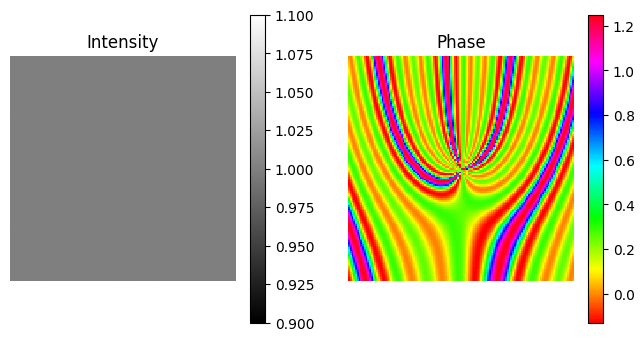

In [9]:
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols)) +0j
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))+0j

    for i in range (rows):
        for j in range (cols):
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/500
            #g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
            g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
            #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
            

    return(mask)

oam_grating_1 = OAMWithGratings(3, N, N, 0, 0)
TotInt(np.exp(1j*oam_grating_1))

What happens when we apply a pitchfork onto a gaussian beam?

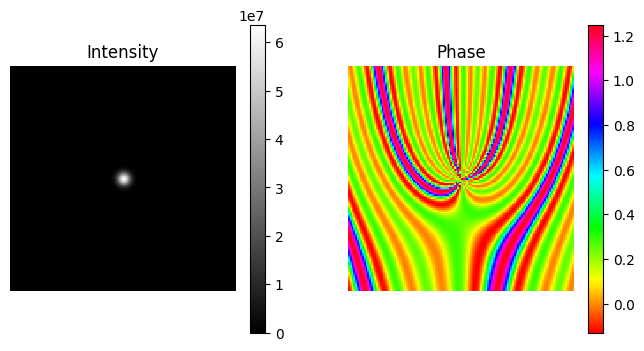

In [10]:
field = LG(r, phi, 0, 0, w0, h, 0, k)
grating_field = field * np.exp(1j*oam_grating_1)
TotInt(grating_field)

I thought that we can see it by applying the fourier transform, but maybe we need to perform Fraunhofer diffraction instead?

What happens when we image on the focal plane? do a fourier transform

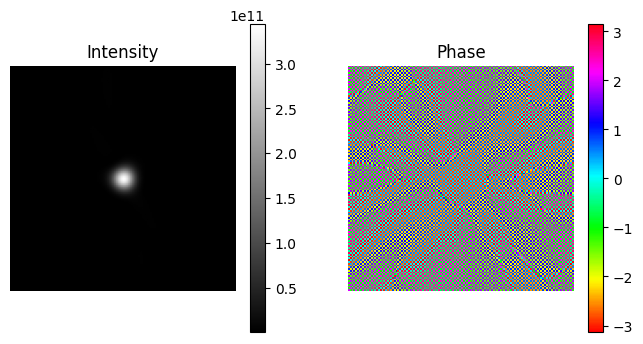

In [11]:
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift

grating_far_field = fftshift(fft2(grating_field))
TotInt(grating_far_field)